## Problem Statement
Music streaming platforms need to provide personalized recommendations to keep users engaged.
This project aims to recommend songs based on similarity in musical attributes.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv("C:\\Users\\twbhaler\\Documents\\AI_ML Course\\Machiene Learning\\Unsupervised Learning\\Project\\rolling_stones_spotify.csv")

In [7]:
df.head()

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   str    
 2   album             1610 non-null   str    
 3   release_date      1610 non-null   str    
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   str    
 6   uri               1610 non-null   str    
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  
 17  durati

Checking for null values

In [9]:
df.isna().sum()

Unnamed: 0          0
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

In [10]:
df.describe()

,Unnamed: 0,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,804.500000,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,464.911282,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,0.000000,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,402.250000,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,804.500000,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,1206.750000,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,1609.000000,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


In [11]:
#drop unnnamed column
df.drop(columns=["Unnamed: 0"], inplace=True)


In [12]:
df.head()

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


In [13]:
df.dtypes

name                    str
album                   str
release_date            str
track_number          int64
id                      str
uri                     str
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
valence             float64
popularity            int64
duration_ms           int64
dtype: object

correlation metrics for numeric columns

In [14]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

print(corr_matrix)

                  track_number  acousticness  danceability    energy  \
track_number          1.000000     -0.035675     -0.112004  0.096314   
acousticness         -0.035675      1.000000      0.070017 -0.363819   
danceability         -0.112004      0.070017      1.000000 -0.300536   
energy                0.096314     -0.363819     -0.300536  1.000000   
instrumentalness     -0.002772      0.061403     -0.031812  0.120261   
liveness              0.188351     -0.117739     -0.516387  0.511188   
loudness              0.100835     -0.237083     -0.249406  0.698039   
speechiness           0.040617     -0.021774     -0.322684  0.417214   
tempo                -0.023934     -0.171003     -0.324398  0.201885   
valence              -0.104567     -0.138803      0.546210  0.046217   
popularity           -0.145115      0.108046      0.141205 -0.057272   
duration_ms           0.156455      0.039128     -0.220045  0.148876   

                  instrumentalness  liveness  loudness  speechi

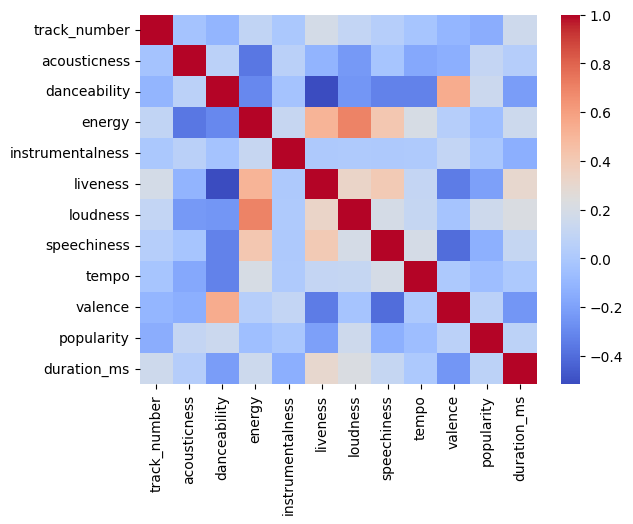

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.show()

correlation metrics shows higher correlation between energy and loudness columns
also, there is relatively higher correlation between valance and dancability
somewhat correlation between energy and liveness as well

dropped columns with higher correlation

In [16]:
#new dataframe after dropping columns with high correlation and numeric columns
df.head()

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


drop track_number column as well

In [17]:
#drop track_number columns
df.drop(columns=["track_number","uri","id"], inplace=True)

In [18]:
df.head()

,name,album,release_date,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


Visualize outliers in all columns using boxplots

In [19]:
from sklearn.preprocessing import StandardScaler

numeric_data = df.select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

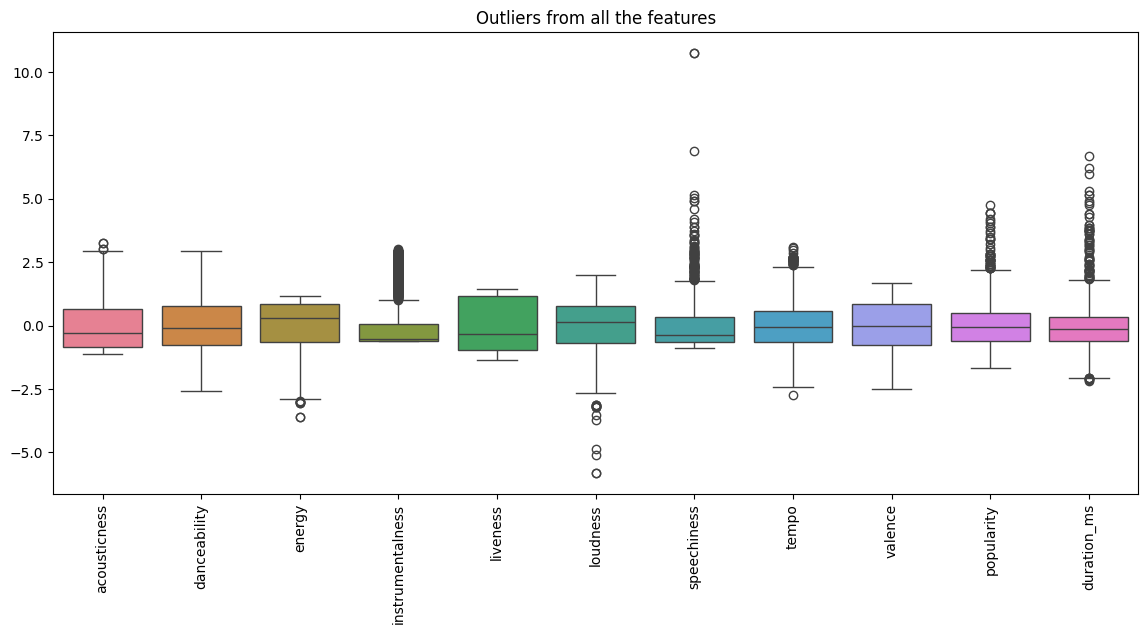

In [20]:
scaled_df = pd.DataFrame(scaled_data, columns=numeric_data.columns)

plt.figure(figsize=(14,6))
sns.boxplot(data=scaled_df)

plt.xticks(rotation=90)
plt.title("Outliers from all the features")
plt.show()

observations:
columns with noticable outliers 
speechiness → heavy extreme values
instrumentalness → many high-end outliers
tempo → some extreme values
popularity → right-skewed outliers
duration_ms → still some extremes

columns with relatively low/no outliers
acousticness
danceability
liveness
valence


In [21]:
Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

data_clean = numeric_data[
    ~((numeric_data < lower_bound) | (numeric_data > upper_bound)).any(axis=1)
]

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_clean)

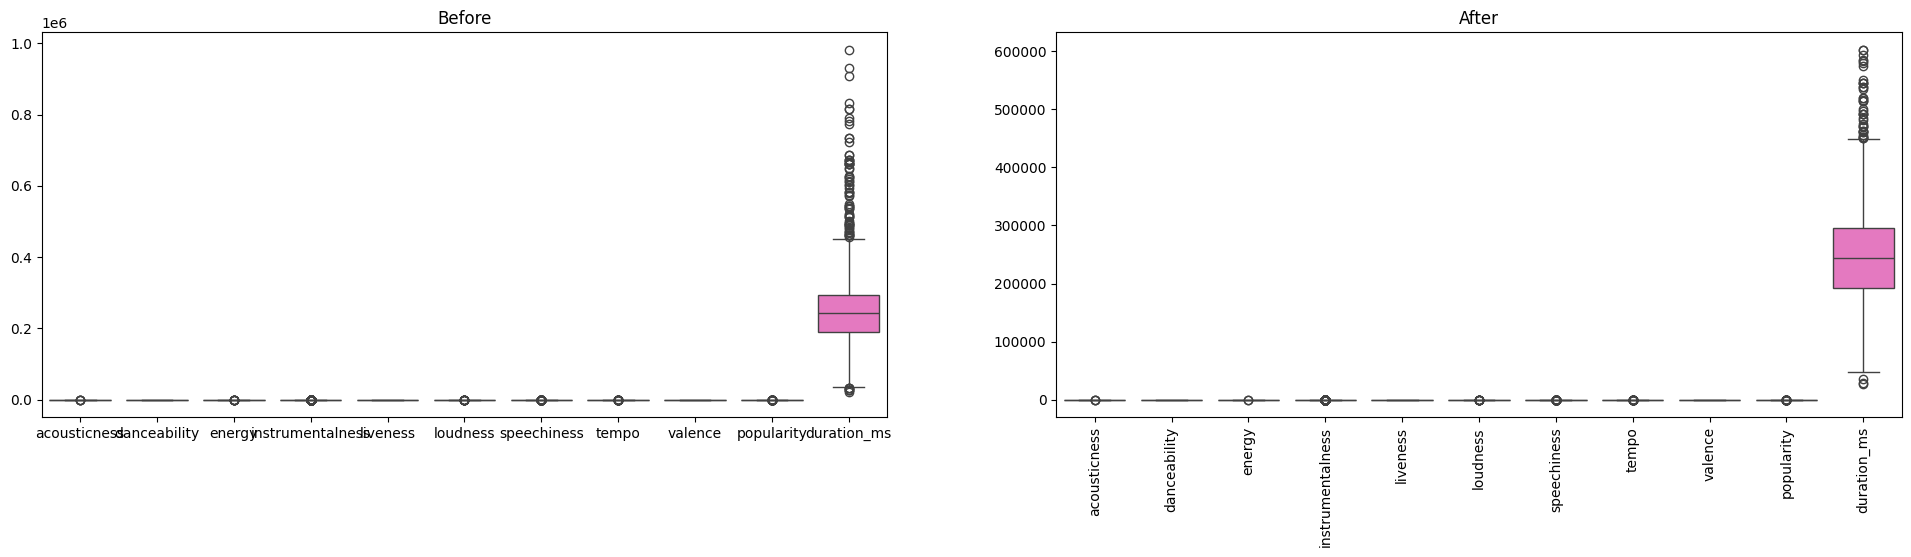

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(24,5))

plt.subplot(1,2,1)
sns.boxplot(data=numeric_data)
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(data=data_clean)
plt.title("After")

plt.xticks(rotation=90)
plt.show()

In [24]:
scaled_df.describe()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1.610000e+03,1.610000e+03,1610.000000,1.610000e+03,1.610000e+03,1.610000e+03,1.610000e+03,1.610000e+03,1.610000e+03,1.610000e+03,1.610000e+03
mean,-5.295971e-17,-7.061294e-17,0.000000,8.826618e-18,4.236777e-16,-7.061294e-17,-2.471453e-16,5.207705e-16,2.647985e-16,-3.530647e-17,8.826618e-17
std,1.000311e+00,1.000311e+00,1.000311,1.000311e+00,1.000311e+00,1.000311e+00,1.000311e+00,1.000311e+00,1.000311e+00,1.000311e+00,1.000311e+00
min,-1.101790e+00,-2.574310e+00,-3.622045,-5.944671e-01,-1.346251e+00,-5.825580e+00,-8.972609e-01,-2.722281e+00,-2.518224e+00,-1.673364e+00,-2.185936e+00
25%,-8.451499e-01,-7.521969e-01,-0.658134,-5.936732e-01,-9.705965e-01,-6.718464e-01,-6.395856e-01,-6.395779e-01,-7.695939e-01,-6.269177e-01,-6.197931e-01
50%,-2.968190e-01,-7.662139e-02,0.312227,-5.446777e-01,-3.215830e-01,1.498844e-01,-3.547865e-01,-5.740179e-02,3.609874e-03,-6.344674e-02,-1.352125e-01
75%,6.742522e-01,7.700528e-01,0.848845,5.370098e-02,1.151950e+00,7.894445e-01,3.310562e-01,5.568537e-01,8.471049e-01,5.000243e-01,3.470298e-01
max,3.270741e+00,2.950239e+00,1.149129,3.012099e+00,1.450668e+00,1.990468e+00,1.074269e+01,3.087213e+00,1.694926e+00,4.766305e+00,6.686341e+00


Utilize suitable visualizations to identify the two albums that should be recommended to anyone based on the number of popular songs in each album

In [25]:
popular_songs = df[df['popularity'] > 60]

In [26]:
#Count popular songs per album
album_popularity = popular_songs.groupby('album')['name'].count().reset_index()
album_popularity.columns = ['album', 'popular_song_count']

In [27]:
#Get the top 2 album
top_albums = album_popularity.sort_values(by='popular_song_count', ascending=False).head(2)
print(top_albums)

                         album  popular_song_count
9  Sticky Fingers (Remastered)                   3
6                 Let It Bleed                   2


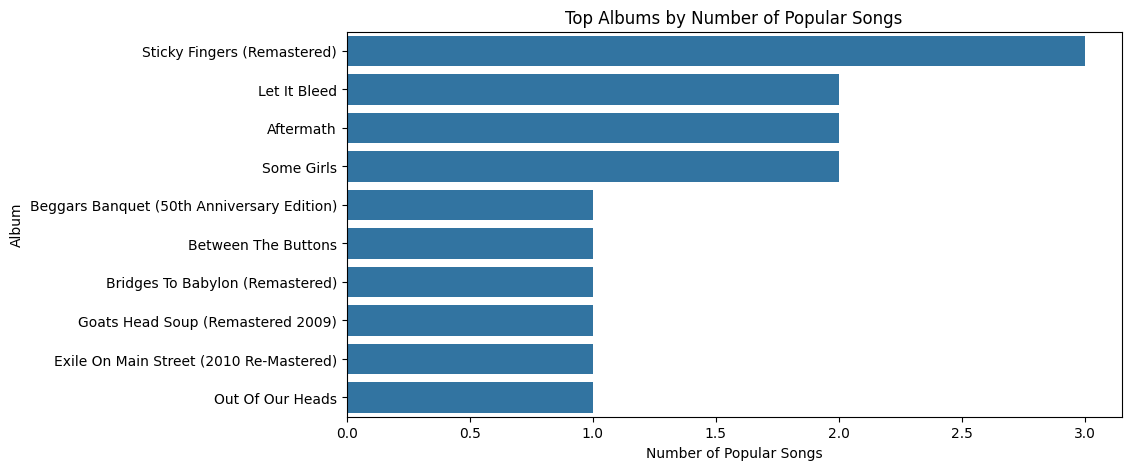

In [28]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=album_popularity.sort_values(by='popular_song_count', ascending=False).head(10),
    x='popular_song_count',
    y='album'
)

plt.title("Top Albums by Number of Popular Songs")
plt.xlabel("Number of Popular Songs")
plt.ylabel("Album")

plt.show()

Observations
Based on popularity 'Sticky Fingers' and 'Let it Bleed' anyone because it contains highest number of popular tracks.

b.	Conduct exploratory data analysis to delve into various features of songs, aiming to identify patterns

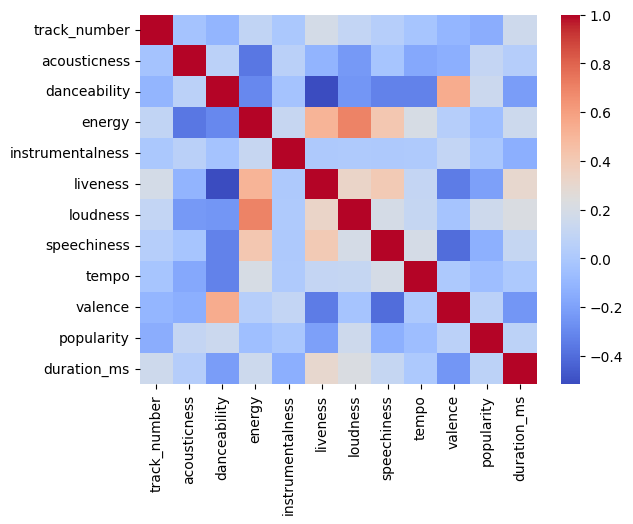

In [29]:
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.show()

Observations and insights
1.String positive correlation between Energy and loudness, indicate that high energy songs are tend to have higher sound intensity
2.ceability and valance have modertely positive correlation, songs with positive mood are more suitable for dancing
3.Liveness and speeciness also shows some moderate positive correlation, which means live recordings often have more spoken elements
4.Acousticness and energy shows strong negative correlation beacause acoustic songs are generally less energetic as compared to electronically produced songs.
5.Liveness and danceability shiws strong negative correlations because liveness have more speechiness less loudness/music hence less danceability
6.Popularity shows weak corelation with almost everything, probably because opularity depend o combination of song features rather than a single song attribute.
7.The absence of strong correlation with popularity suggests that recommendation systems should rely on similarity-based clustering rather than popularity-driven filtering

c.	Examine the relationship between a song's popularity and various factors, exploring how this correlation has evolved
We have explored correlation metrics of popularity with other features in the dataset in previous section

Plot scatterplot of popularity with other features in dataset

In [30]:
print(df.columns)

Index(['name', 'album', 'release_date', 'acousticness', 'danceability',
       'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness',
       'tempo', 'valence', 'popularity', 'duration_ms'],
      dtype='str')


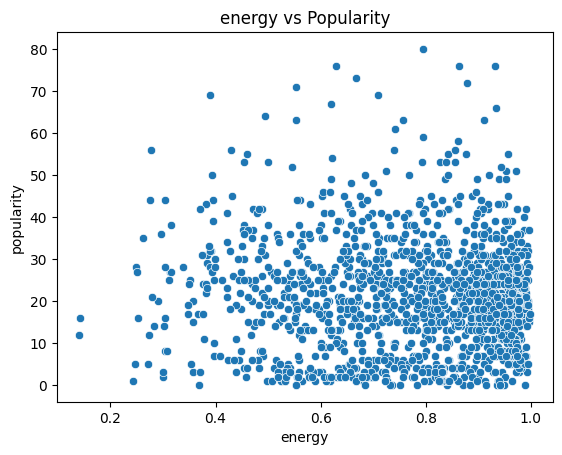

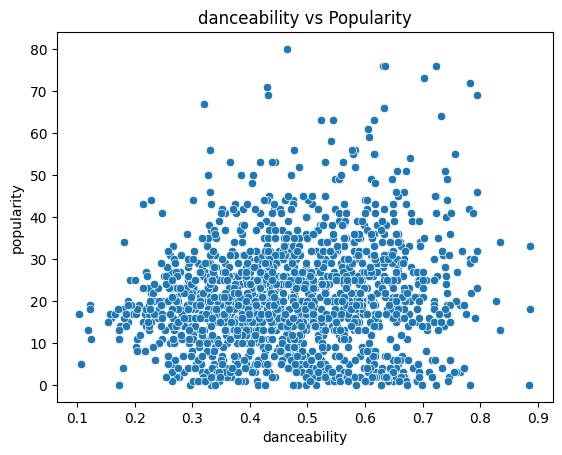

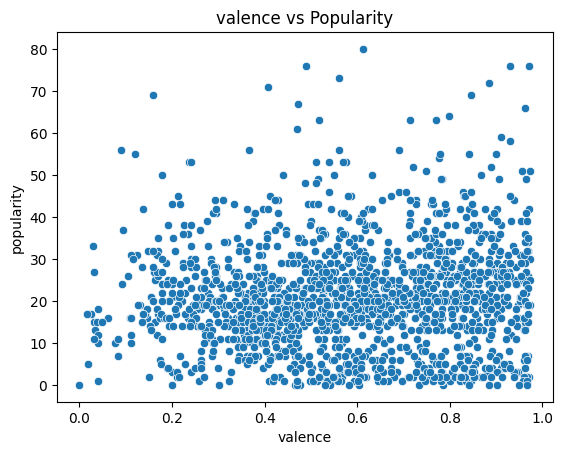

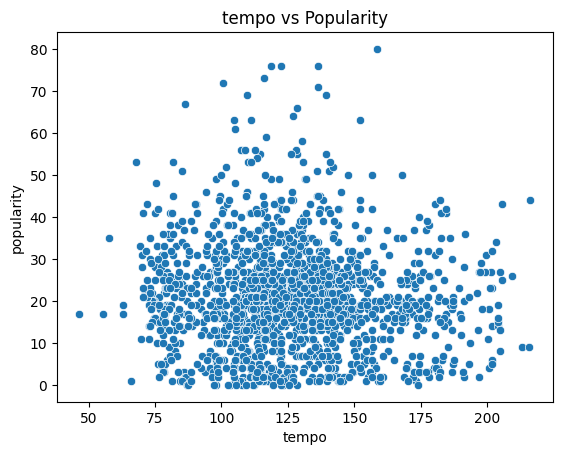

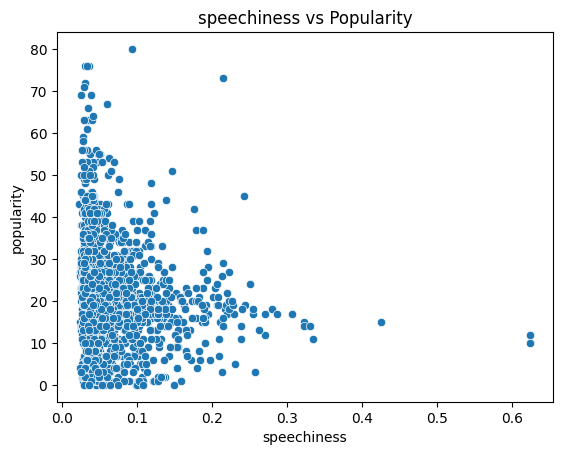

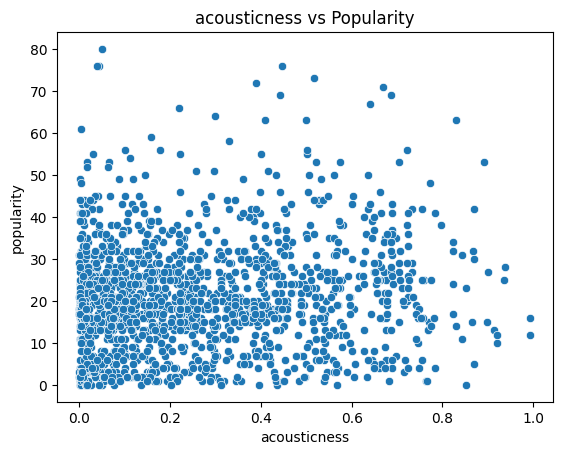

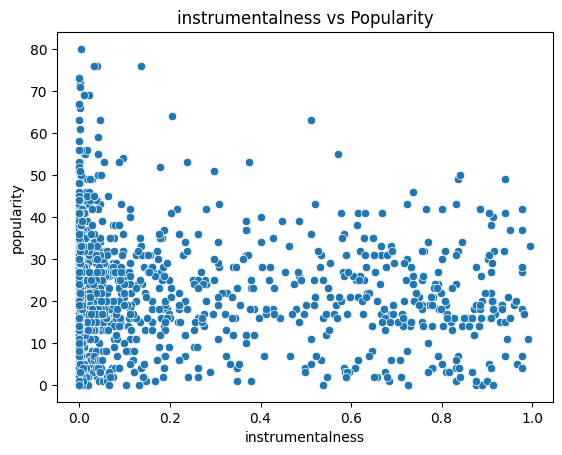

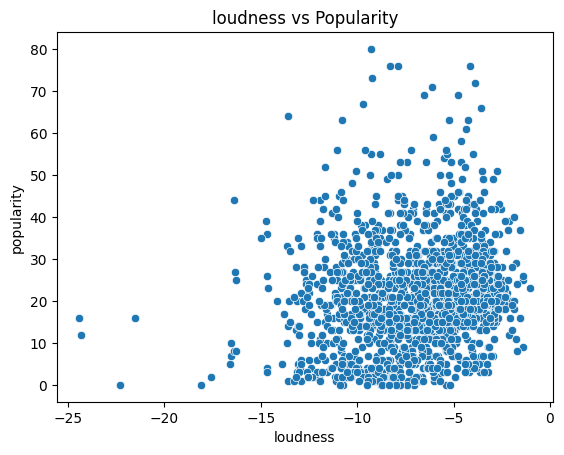

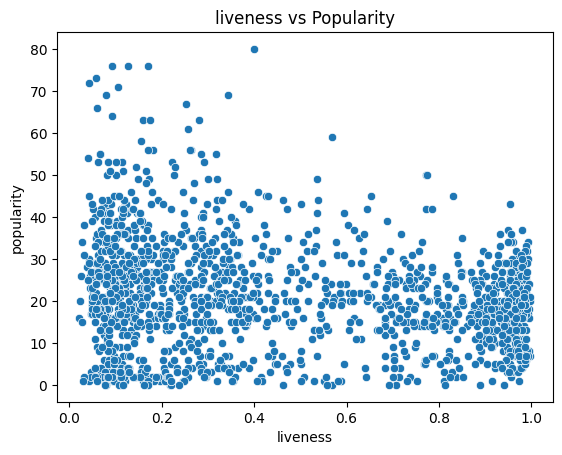

In [31]:
features = ['energy','danceability','valence','tempo','speechiness','acousticness','instrumentalness','loudness','liveness']

for f in features:
    sns.scatterplot(x=df[f], y=df['popularity'])
    plt.title(f"{f} vs Popularity")
    plt.show()

Dimensionality Reduction using PCA

In [55]:
data_clean = data_clean.reset_index(drop=True)

In [56]:
X = data_clean.drop(columns=['popularity'])
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [57]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)


Visualize PCA and find optimum number of clusters

In [34]:
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

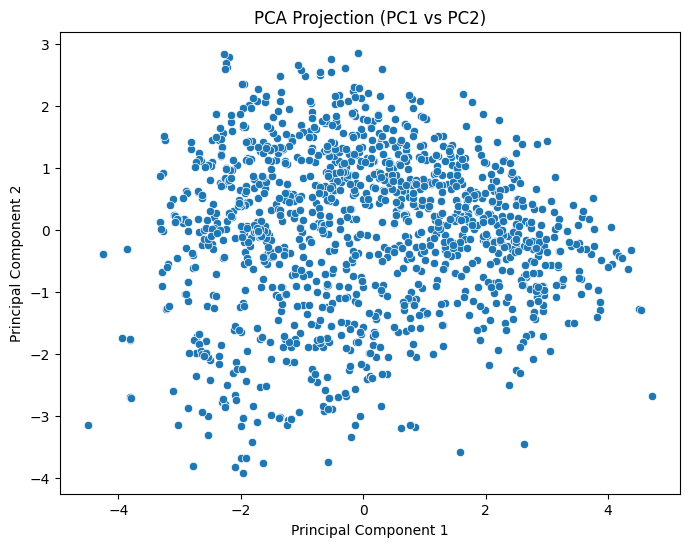

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'])

plt.title("PCA Projection (PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Observations - From above chart, we can say that obvious clusters are absernt but dence central regoin shows that many songs share simillat charachteristics. There are some outliers too.

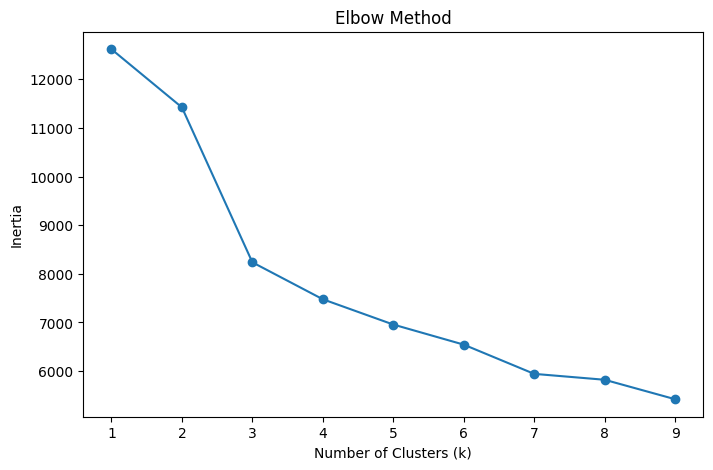

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

Observation - Optimum numbers of custers would be 3 beacuse after point 3, curve starts to flatten sharply

Compute silhouette scores

In [37]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    
    score = silhouette_score(X_pca, labels)
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.197
k=3, silhouette score=0.200
k=4, silhouette score=0.172
k=5, silhouette score=0.182
k=6, silhouette score=0.160
k=7, silhouette score=0.175
k=8, silhouette score=0.170
k=9, silhouette score=0.175


In [38]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

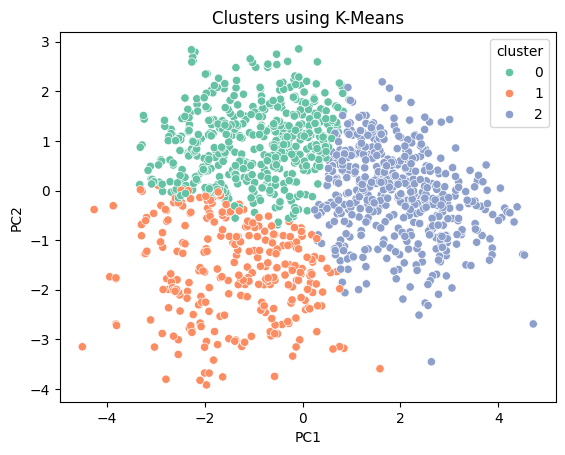

In [40]:
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

pca_df['cluster'] = clusters

sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='cluster', 
    data=pca_df,
    palette='Set2'
)

plt.title("Clusters using K-Means")
plt.show()

Observations -
the plot claerly shows 3 clusters. 
Cluster 0 - these songs has good balance of energy ,daceability and mood
Cluster 1 - Relatively smaller cluster.Likely more acoustic,low enery or calm songs
Cluster 2 - High energy loud and fast tracks

In [41]:
cluster_analysis = data_clean.copy()
cluster_analysis['cluster'] = clusters

cluster_analysis.groupby('cluster').mean()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
cluster,,,,,,,,,,,
0,0.163969,0.569005,0.784363,0.115197,0.273171,-7.253309,0.048363,121.892877,0.766882,22.134168,221308.767442
1,0.488181,0.476988,0.562920,0.060375,0.322529,-9.481176,0.045915,112.871161,0.442674,22.380805,249339.783282
2,0.175369,0.369760,0.923458,0.089812,0.808326,-5.182827,0.096138,137.818254,0.474988,18.176923,289702.515385


Observation -
Popularity does not significantly differ across clusters, reinforcing that musical characteristics alone do not determine song popularity

## Generate song recommendation using item collaborative filtering and cosine symillarity

In [47]:
df_model = df.loc[data_clean.index].copy()
df_model = df_model.reset_index(drop=True)

In [58]:
X = X_pca
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X)


In [59]:
song_index = pd.Series(df_model.index, index=df_model['name']).drop_duplicates()

In [64]:

import numpy as np
import pandas as pd

def recommend_songs(song_name, df_model, similarity_matrix, top_n=5):
    
    if song_name not in song_index:
        return "Song not found"
    
    idx = song_index[song_name]
    
    # ✅ Handle duplicate song names
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]
    
    sim_scores = similarity_matrix[idx]
    
    # Ensure 1D array
    sim_scores = np.array(sim_scores).flatten()
    
    # Get top similar indices
    top_indices = np.argsort(sim_scores)[::-1][1:top_n+1]
    
    return df_model['name'].iloc[top_indices].values

Test the fuction by passing a song name to see recommended songs

In [65]:
recommend_songs("I Am Waiting", df_model, similarity_matrix)

<ArrowStringArray>
[                 'I Am Waiting',                  'I Am Waiting',
 'Mona - Blues In Rhythm / 1964', 'Mona - Blues In Rhythm / 1964',
    'Lady Jane - Stereo Version']
Length: 5, dtype: str